## Import the required libraries

In [80]:
color_drop_out={
        'Graduate': '#0072B2',
        'Dropout': '#D55E00'
    }

In [81]:
# Data pre-processing
from sklearn.preprocessing import StandardScaler

# Data splitting
from sklearn.model_selection import train_test_split

# Machine learning Models
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import lightgbm as lgb


# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [82]:
# PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import pyspark.sql.functions as F

# Data wrangling
import numpy as np
import pandas as pd  # Still needed for visualization conversions
from tqdm import tqdm
import seaborn as sns

# Data Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# PySpark ML imports
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder, PCA
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, LinearSVC
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline

# For sklearn metrics (can still use for final evaluation)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc



Initialise the Spark session

In [83]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Student Performance Analysis") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

### 1. Load and understand the data

In [84]:
# Path is RELATIVE to the folder containing this notebook.
# (It used to be "/data/..." — a leading "/" points at the filesystem root, which only worked on Colab.)
#
# IMPORTANT: the UCI file uses a SEMICOLON ";" as the separator, whereas
# Spark defaults to a comma ",". Without option("sep", ";") all 35 columns
# collapse into ONE column and every cell below fails with "cannot resolve column".
df = spark.read.option("header", "true") \
               .option("sep", ";") \
               .option("inferSchema", "true") \
               .csv("data/student's dropout dataset.csv")

print(f"Loaded: {df.count()} rows · {len(df.columns)} columns")
df.show(5)

Loaded: 4424 rows · 37 columns
+--------------+----------------+-----------------+------+----------------------------+----------------------+------------------------------+-----------+----------------------+----------------------+-------------------+-------------------+---------------+---------+-------------------------+------+-----------------------+------+------------------+-----------------+-------------+-----------------------------------+-----------------------------------+--------------------------------------+-----------------------------------+--------------------------------+----------------------------------------------+-----------------------------------+-----------------------------------+--------------------------------------+-----------------------------------+--------------------------------+----------------------------------------------+-----------------+--------------+-----+--------+
|Marital status|Application mode|Application order|Course|Daytime/evening attendance\t

# Data dictionary

Source: <https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success>

## 1. Personal & admission information

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Marital status** | Marital status of the student (1 = single, 2 = married, 3 = divorced, etc.) | 1 | Categorical |
| **Application mode** | How the student applied (e.g. 1 = general contingent, 17 = transfer, 15 = international, 39 = re-admission) | 17 | Categorical |
| **Application order** | Preference order of the application (1 = first choice) | 1 | Numeric |
| **Course** | Degree programme code | 9773 | Categorical |
| **Daytime/evening attendance** | Attendance type: 1 = daytime, 0 = evening | 1 | Binary |
| **Previous qualification** | Qualification obtained before enrolling (e.g. 1 = secondary, 2 = technical secondary, 4 = bachelor, 19 = foreign) | 1 | Categorical |
| **Previous qualification (grade)** | Grade of the previous qualification | 122.0 | Numeric |
| **Nacionality** | Nationality (1 = Portuguese, 2 = EU, 6 = non-EU, etc.) — misspelt in the source file | 1 | Categorical |

---

## 2. Family background

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Mother's qualification** | Mother's education level (1 = none, 19 = bachelor, 37 = master, 38 = doctorate) | 37 | Categorical |
| **Father's qualification** | Father's education level (same coding as the mother's column) | 38 | Categorical |
| **Mother's occupation** | Mother's occupation (codes 1–9: manual worker, clerk, professional, manager, etc.) | 9 | Categorical |
| **Father's occupation** | Father's occupation | 9 | Categorical |

---

## 3. Admission and personal circumstances

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Admission grade** | Admission score (range 95–200) | 141.5 | Numeric |
| **Displaced** | Whether the student is displaced from their home region (0 = no, 1 = yes) | 0 | Binary |
| **Educational special needs** | Whether the student has special educational needs (0 = no, 1 = yes) | 0 | Binary |
| **Debtor** | Whether the student owes tuition (0 = no, 1 = yes) | 0 | Binary |
| **Tuition fees up to date** | Whether tuition is fully paid (0 = no, 1 = yes) | 1 | Binary |
| **Gender** | Gender (0 = female, 1 = male) | 1 | Binary |
| **Scholarship holder** | Whether the student holds a scholarship (0 = no, 1 = yes) | 0 | Binary |
| **Age at enrollment** | Age when enrolling | 19 | Numeric |
| **International** | International student (0 = no, 1 = yes) | 0 | Binary |

---

## 4. First semester — curricular data

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Curricular units 1st sem (credited)** | Units credited from prior study (exempted) | 0 | Numeric |
| **Curricular units 1st sem (enrolled)** | Units the student enrolled in | 6 | Numeric |
| **Curricular units 1st sem (evaluations)** | Number of assessments taken in semester 1 | 9 | Numeric |
| **Curricular units 1st sem (approved)** | Units passed in semester 1 | 5 | Numeric |
| **Curricular units 1st sem (grade)** | Average grade in semester 1 | 13.4 | Numeric |
| **Curricular units 1st sem (without evaluations)** | Units with no assessment taken (missed exams) | 0 | Numeric |

---

## 5. Second semester — curricular data

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Curricular units 2nd sem (credited)** | Units credited in semester 2 | 0 | Numeric |
| **Curricular units 2nd sem (enrolled)** | Units enrolled in semester 2 | 6 | Numeric |
| **Curricular units 2nd sem (evaluations)** | Number of assessments taken in semester 2 | 10 | Numeric |
| **Curricular units 2nd sem (approved)** | Units passed in semester 2 | 6 | Numeric |
| **Curricular units 2nd sem (grade)** | Average grade in semester 2 | 12.4 | Numeric |
| **Curricular units 2nd sem (without evaluations)** | Units with no assessment taken in semester 2 | 0 | Numeric |

---

## 6. Economic context at enrolment

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Unemployment rate** | National unemployment rate (%) | 10.8 | Numeric |
| **Inflation rate** | Inflation rate (%) | 1.4 | Numeric |
| **GDP** | GDP growth (%) | 1.74 | Numeric |

---

## 7. Target variable

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Target** | Final academic outcome: `Dropout`, `Enrolled` or `Graduate` | Graduate | Categorical |

---

## Summary of the variable groups

| Group | Content | Purpose |
|------------|----------------|-----------|
| Personal / admission | Individual characteristics and entry route | Describe the student at intake |
| Family | Parents' education and occupation | Capture family influence |
| Academic (semesters) | Study results per semester | Predict dropout or graduation |
| Economic | National economic conditions | Capture the wider context |
| Target | Class label | Variable to be predicted |

### 2. Clean the data before further processing (feature encoding, normalisation, training, etc.)

Two column names in the source file need fixing:

- `"Nacionality"` — misspelt, it should be `"Nationality"`
- `"Daytime/evening attendance\t"` — carries a stray **tab character (`\t`)** at the end

In [85]:
data = df.withColumnRenamed('Nacionality', 'Nationality')\
         .withColumnRenamed('Daytime/evening attendance\t', 'Daytime/evening attendance')

In [86]:
print(f"Number of rows: {data.count()}")
print(f"Number of columns: {len(data.columns)}")

Number of rows: 4424
Number of columns: 37


In [87]:
data.printSchema()

root
 |-- Marital status: integer (nullable = true)
 |-- Application mode: integer (nullable = true)
 |-- Application order: integer (nullable = true)
 |-- Course: integer (nullable = true)
 |-- Daytime/evening attendance: integer (nullable = true)
 |-- Previous qualification: integer (nullable = true)
 |-- Previous qualification (grade): double (nullable = true)
 |-- Nationality: integer (nullable = true)
 |-- Mother's qualification: integer (nullable = true)
 |-- Father's qualification: integer (nullable = true)
 |-- Mother's occupation: integer (nullable = true)
 |-- Father's occupation: integer (nullable = true)
 |-- Admission grade: double (nullable = true)
 |-- Displaced: integer (nullable = true)
 |-- Educational special needs: integer (nullable = true)
 |-- Debtor: integer (nullable = true)
 |-- Tuition fees up to date: integer (nullable = true)
 |-- Gender: integer (nullable = true)
 |-- Scholarship holder: integer (nullable = true)
 |-- Age at enrollment: integer (nullable = 

In [88]:
data.describe().show()

+-------+------------------+------------------+------------------+-----------------+--------------------------+----------------------+------------------------------+------------------+----------------------+----------------------+-------------------+-------------------+------------------+-------------------+-------------------------+-------------------+-----------------------+-------------------+-------------------+------------------+--------------------+-----------------------------------+-----------------------------------+--------------------------------------+-----------------------------------+--------------------------------+----------------------------------------------+-----------------------------------+-----------------------------------+--------------------------------------+-----------------------------------+--------------------------------+----------------------------------------------+------------------+------------------+--------------------+--------+
|summary|    Marit

### What the `describe` output tells us

- The data has 35 columns (features).
- There are no missing values.
- The variables are a mix of categorical and numeric types.

Most categorical variables in the downloaded file have already been converted to numeric codes. For exploratory data analysis (EDA), however, some of these columns are mapped back to their original category labels so the charts are readable.

In [89]:
# Checking for null values
# print("Null value counts per column:")
# null_counts = df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns])

# null_counts.show()

Before starting the visualisation work, take a **copy** of the original DataFrame.

This keeps the raw data intact and avoids accidentally changing it while preparing charts.

In [90]:
data_viz = data

In [91]:
data.select('Target').distinct().show()

+--------+
|  Target|
+--------+
|Enrolled|
| Dropout|
|Graduate|
+--------+



The `Target` column holds three values:

| Value | Meaning | Description |
| ---------- | ---------------- | ------------------------------------------------ |
| `Graduate` | Graduated | The student completed the programme. |
| `Dropout` | Dropped out | The student left before completing the programme. |
| `Enrolled` | Still enrolled | The student is still studying. |

In its original form this is a **multi-class classification** problem with three classes: `Graduate`, `Dropout`, `Enrolled`.

Having checked the distinct values of **Target**, the next step is to visualise how students are distributed across the three groups using a **pie chart**.

In [92]:
# NOTE: do NOT assign the aggregation back onto `data_viz`.
# This cell used to read `data_viz = data_viz.groupBy(...)`, which left `data_viz`
# with only [Target, count] and broke EVERY later cell that uses `data_viz`.
target_counts = (
    data_viz
    .groupBy("Target")
    .count()
    .orderBy("Target")
)
target_counts.show()

+--------+-----+
|  Target|count|
+--------+-----+
| Dropout| 1421|
|Enrolled|  794|
|Graduate| 2209|
+--------+-----+



In [93]:
target_counts_pd = target_counts.toPandas()

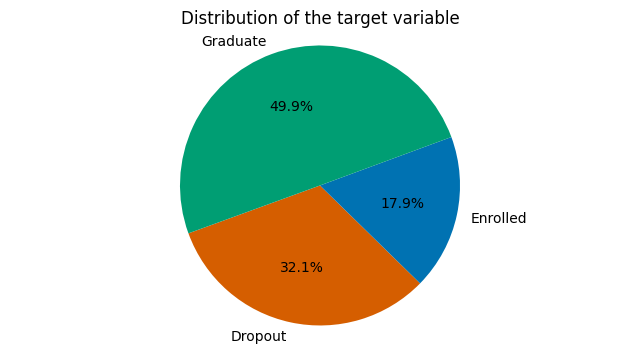

In [94]:
values = target_counts_pd['count']
labels = target_counts_pd['Target'].astype(str)

plt.figure(figsize=(8, 4))
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=200,
    colors=['#D55E00', '#0072B2', '#009E73'][:len(values)]
)

plt.title('Distribution of the target variable')
plt.axis('equal')
plt.show()

| Class | Percentage | Meaning |
| --------------- | ---------- | ---------------------------------------- |
| **Graduate** | 49.9% | Completed the programme |
| **Dropout** | 32.1% | Left before completing |
| **Enrolled** | 17.9% | Still studying |

- About half of the students in the dataset graduated (≈ 50%).
- Roughly one third (32%) dropped out — this is the group the risk model needs to identify.
- The remaining 18% are still enrolled; their final outcome is not yet known.

## Binary encoding of the target

In the source data the `Target` column has three values:

- `Dropout` — the student left the programme
- `Enrolled` — the student is still studying
- `Graduate` — the student completed the programme

The research question here is a **binary** one:

> "Will this student drop out or not?"

So the target is encoded as:

- **1** — Dropout
- **0** — Not dropout (both `Enrolled` and `Graduate`)

In [95]:
df_train = data.filter(F.col("Target").isin(["Graduate", "Dropout"]))
df_enrolled = data.filter(F.col("Target") == "Enrolled")

In [96]:
# Convert the 'Target' column to numerical using binary encoding
df_train = df_train.withColumn('Target_Encoded',
                               F.when(F.col('Target') == 'Dropout', 1).otherwise(0))

# Convert to pandas for visualization
df_train_pd = df_train.toPandas()

# Illustrate the distribution of the encoded target variable
value_counts_series = df_train_pd['Target_Encoded'].value_counts()
labels_map = {0: 'Not dropout', 1: 'Dropout'}
display_names = [labels_map[val] for val in value_counts_series.index.to_list()]

fig = px.pie(values=value_counts_series.values,
             names=display_names)

fig.update_traces(textposition='inside', textinfo='percent+label',
                  marker=dict(colors=['#009E73', '#D55E00'])) # Using different colors for binary

fig.update_layout(showlegend=False, height=400, width=800,
                  title='Target distribution after binary encoding')
fig.show()

### Observation

The pie chart below shows the share of students who dropped out (1) versus those who did not (0):

- **0 — did not drop out: 60.9%**
- **1 — dropped out: 39.1%**

The dataset is therefore **moderately imbalanced**: the non-dropout group is the majority.

This matters during training, because a model can score well simply by favouring the majority class (**class imbalance bias**). It is the reason the models later use `is_unbalance` / `scale_pos_weight` and are selected on AUC rather than accuracy.

## Age at enrollment

In [97]:
fig = px.histogram(
    df_train_pd,
    x='Age at enrollment',
    facet_col='Target',
    color='Target',
    nbins=30,
    histnorm='percent',
    opacity=0.85,
    color_discrete_map={
        'Graduate': '#0072B2',
        'Dropout': '#D55E00'
    }
)

fig.update_layout(
    title={
        'text': 'Age at enrollment by academic outcome',
        'x': 0.5
    },
    xaxis_title='Age at enrollment',
    yaxis_title='Percentage (%)',
    height=450,
    width=900,
    showlegend=False
)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()


### Observation

- The distribution is right-skewed: most students are in their late teens to early twenties.
- The dropout rate rises among students in their mid-twenties to early thirties.

The next set of charts is mostly pie charts. To avoid repeating code, two helper functions are defined: one builds a dictionary of target counts per category, and the other turns those dictionaries into pie chart traces.

In [98]:
def get_dictionaries(category_list, dfcolumn_name, target_col, dictionary_list):
  '''This function returns a list of dictionaries for value count of each target label per category'''
  # Convert to pandas for easier manipulation
  df_train_pd = df_train.toPandas()

  for each_category in category_list:
    a_dictionary = dict(df_train_pd[df_train_pd[dfcolumn_name]== each_category][target_col].value_counts())
    dictionary_list.append(a_dictionary)
  return dictionary_list

In [99]:
def make_pie(dictionary_list, trace_list, colors_list, textposition = 'inside'):
  '''This function returns a list of traces for pie charts'''
  for dictionary in dictionary_list:
    trace = go.Pie(values = list(dictionary.values()), labels = list(dictionary.keys()),
           textposition = textposition, textinfo='percent+label',
           marker=dict(colors=colors_list))
    trace_list.append(trace)
  return trace_list

## Gender

In [100]:
# Change gender from numerical to categorical
df_train = df_train.withColumn('Gender',
                               F.when(col('Gender') == 1, 'Male').otherwise('Female'))

In [101]:
df_train.select('Gender').show()

+------+
|Gender|
+------+
|  Male|
|  Male|
|  Male|
|Female|
|Female|
|  Male|
|Female|
|  Male|
|Female|
|Female|
|Female|
|Female|
|Female|
|Female|
|Female|
|Female|
|Female|
|Female|
|Female|
|Female|
+------+
only showing top 20 rows


In [102]:
df_train_pd = df_train.toPandas()
percent_count = (df_train_pd['Gender'].value_counts(normalize=True) * 100).round(1)

df_plot = percent_count.reset_index()
df_plot.columns = ['Gender', 'Percentage (%)']

fig = px.bar(
    df_plot,
    x='Percentage (%)',
    y='Gender',
    orientation='h',
    text='Percentage (%)',
    color='Gender',
    color_discrete_map={
        'Male': '#1A4A96',    # blue
        'Female': '#FF8DA1'  # pink
    }
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Gender distribution in the training data',
        'x': 0.5
    },
    xaxis=dict(
        title='Percentage (%)',
        range=[0, 100],
        ticksuffix='%'
    ),
    yaxis_title='Gender',
    height=420,
    width=720,
    showlegend=False,
    font=dict(size=14)
)

fig.show()


### Observation

- Female students make up about **65.6%** of the dataset.
- Male students make up **34.4%**.

The horizontal bar chart shows a clear gender imbalance in the sample.

Having looked at the overall gender split, the next step is to break gender down by academic outcome (`Target`) — in particular, which group has the higher dropout rate.

In [103]:
# Getting dictionaries for genders
genders = [row.Gender for row in df_train.select('Gender').distinct().collect()]
genders_dictionaries = get_dictionaries(genders, 'Gender', 'Target', [])
genders_dictionaries

[{'Graduate': 1661, 'Dropout': 720}, {'Dropout': 701, 'Graduate': 548}]

In [104]:
df_plot = ( df_train_pd .groupby(['Gender', 'Target']) .size() .rename('count') .reset_index() )
df_plot['Percentage (%)'] = ( df_plot .groupby('Gender')['count'] .transform(lambda x: x / x.sum() * 100) )
fig = px.bar(
    df_plot,
    x='Target',
    y='Percentage (%)',
    color='Gender',
    barmode='group',
    text=df_plot['Percentage (%)'].round(1).astype(str) + '%',
    color_discrete_map={
        'Male': '#1A4A96',    # blue
        'Female': '#FF8DA1'  # pink
    }
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Academic outcome by gender',
        'x': 0.5
    },
    yaxis_title='Percentage (%)',
    xaxis_title='Academic outcome',
    yaxis=dict(
        range=[0, 100]
    ),
    height=450,
    width=800,
    uniformtext_minsize=12,
    uniformtext_mode='hide'
)

fig.show()


### Observation

**Male students**
- Graduate: 43.9%
- Dropout: 56.1%

**Female students**
- Graduate: 69.8%
- Dropout: 30.2%

The dropout rate among female students is markedly lower than among male students.

### Course distribution

In [105]:
from pyspark.sql import functions as F

# The course codes in the UCI file are the ORIGINAL codes (33, 171, 8014 ... 9991), NOT 1..17.
# Using keys 1..17 makes every `Course_name` NULL and leaves the charts empty.
course_mapping = {
    33:   'Biofuel Production Technologies',
    171:  'Animation and Multimedia Design',
    8014: 'Social Service (evening attendance)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equiniculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening attendance)',
}

mapping_expr = F.create_map([F.lit(x) for pair in course_mapping.items() for x in pair])
df_train = df_train.withColumn('Course_name', mapping_expr[F.col('Course')])

# Fail fast: any remaining NULL means the mapping does not match the data
n_null = df_train.filter(F.col('Course_name').isNull()).count()
assert n_null == 0, f'{n_null} rows have an unmapped course code — check course_mapping'
print(f'Mapped {len(course_mapping)} degree programmes, no NULL values left')

Mapped 17 degree programmes, no NULL values left


Total number of students in each course, to see which programmes attract the most students.

In [106]:
# Re-materialise from Spark AFTER `Course_name` was added in the cell above.
# (It previously reused `df_train_pd` built back in cell 41, before that column existed.)
df_train_pd = df_train.toPandas()
df_course = df_train_pd.copy()
print(f'{len(df_course)} rows · has Course_name column: {"Course_name" in df_course.columns}')

3630 rows · has Course_name column: True


In [107]:
df_course_rate = (
    df_course
    .groupby(['Course_name', 'Target'])
    .size()
    .rename('count')
    .reset_index()
)

df_course_rate['Dropout_rate (%)'] = (
    df_course_rate
    .groupby('Course_name')['count']
    .transform(lambda x: x / x.sum() * 100)
)

# Keep only the Dropout rows
df_course_rate = df_course_rate[df_course_rate['Target'] == 'Dropout']

# Sort by rate, descending
df_course_rate = df_course_rate.sort_values(
    'Dropout_rate (%)', ascending=False
)

In [108]:
import plotly.express as px

fig = px.bar(
    df_course_rate,
    x='Dropout_rate (%)',
    y='Course_name',
    orientation='h',
    text=df_course_rate['Dropout_rate (%)'].round(1).astype(str) + '%',
    color='Dropout_rate (%)',
    color_continuous_scale='Reds'
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Dropout rate by degree programme',
        'x': 0.5
    },
    xaxis_title='Dropout rate (%)',
    yaxis_title='Degree programme',
    xaxis=dict(range=[0, 100]),
    height=600,
    width=900,
    coloraxis_showscale=False,
    uniformtext_minsize=11,
    uniformtext_mode='hide'
)

fig.show()


In [109]:
df_rate = (
    df_train_pd
    .groupby(['Course_name', 'Target'])
    .size()
    .rename('count')
    .reset_index()
)

df_rate['Percent'] = (
    df_rate
    .groupby('Course_name')['count']
    .transform(lambda x: x / x.sum() * 100)
)

fig = px.bar(
    df_rate,
    x='Percent',
    y='Course_name',
    color='Target',
    orientation='h',
    barmode='stack',
    color_discrete_map=color_drop_out
)

fig.update_layout(
    title={
        'text': 'Dropout and graduation rate by degree programme',
        'x': 0.5
    },
    xaxis_title='Percentage (%)',
    yaxis_title='Degree programme',
    xaxis=dict(range=[0, 100]),
    height=650,
    width=1000
)

fig.show()


### Observation

**1. Programmes with the highest graduation rate**

Nursing (71.5%), Social Service — evening attendance (57.2%) and Journalism and Communication (59.2%) have very high graduation rates, suggesting students in these programmes tend to stay and complete.

**2. Programmes with the highest dropout rate**

`Biofuel Production Technologies` (66.7%), `Social Service` (69.9%) and `Management — evening attendance` (50.7%) show high dropout, which may reflect programme difficulty or weaker perceived career prospects.

**3. Programmes with many students still enrolled**

`Informatics Engineering` (37.6%), `Veterinary Nursing` (22.3%) and `Management` (28.4%) have a high share of "Enrolled" students, which can indicate a newer programme or a longer expected duration.

### Marital status

In [110]:
# Map the numeric codes to text labels.
# NOTE: the `otherwise` branch must return the SAME TYPE as the `when` branches.
# Returning the original numeric column makes Spark fail casting 'Single' -> BIGINT.
data_viz = data_viz.withColumn('Marital status',
                               when(col('Marital status') == 1, 'Single')
                               .when(col('Marital status') == 2, 'Married')
                               .when(col('Marital status') == 3, 'Widower')
                               .when(col('Marital status') == 4, 'Divorced')
                               .when(col('Marital status') == 5, 'Facto union')
                               .when(col('Marital status') == 6, 'Legally Separated')
                               .otherwise(col('Marital status').cast('string')))

In [111]:
# Bar chart for Marital status
# Convert to pandas for visualization
data_viz_pd = data_viz.toPandas()
count = data_viz_pd['Marital status'].value_counts()
fig = px.bar(count,  orientation= 'h', text_auto=True)

fig.update_traces(marker=dict(color=['red', 'orange']))
fig.update_layout(height=500, width=800,
                  title='Marital status of the students',
                  showlegend = False,
                  font=dict(size=14),
                  xaxis_title = 'Count',
                  yaxis_title = 'Marital status')
fig.show()

- The great majority of students are **single** (3,919 students, roughly 88–90% of the sample). This is expected, since most students are of typical university age.

- A small share are **married** (379 students, about 8–9%), which suggests a group of older or part-time students.

- The remaining categories are very small:

| Status | Count | Note |
| ----------------- | -------- | ------------------------------------------------------ |
| Divorced | 91 | Likely older students or those returning to study |
| Facto union | 25 | Living together without a registered marriage |
| Legally separated | 6 | Negligible |
| Widower | 4 | Very rare |

In [112]:
# Convert to pandas for visualization
data_viz_pd = data_viz.toPandas()

fig = px.histogram(data_viz_pd, x='Marital status', color = 'Target',
                   width = 1200, height = 500,
                   text_auto='.1f', color_discrete_sequence=px.colors.qualitative.Dark2,
                   barnorm = 'percent', barmode = 'group')

fig.update_layout(title='Marital status', yaxis_title = '% of students')

fig.show()

Marital status is clearly related to the academic outcome. Single students have the highest graduation rate, while students in more complex family situations (married, separated, divorced) drop out considerably more often — plausibly because of competing demands on their time, finances or emotional capacity.

In [113]:
def sub_plots(chart_to_plot, row, col):
  '''This function generates the list of subplots'''
  cols = chart_to_plot * col
  rows = [cols] * row
  return rows

### Financial situation of the students

Next, the financial situation is analysed to see how scholarship status, debt status and tuition payment status relate to the dropout rate.

In [114]:
# Converting columns back to categorical
data_viz = data_viz.withColumn('Debtor',
                               when(col('Debtor') == 1, 'Yes').otherwise('No'))
data_viz = data_viz.withColumn('Tuition fees up to date',
                               when(col('Tuition fees up to date') == 1, 'Yes').otherwise('No'))
data_viz = data_viz.withColumn('Scholarship holder',
                               when(col('Scholarship holder') == 1, 'Yes').otherwise('No'))

In [115]:
# Getting dictionaries for students in debt/ not in debt
debt = [row.Debtor for row in data_viz.select('Debtor').distinct().collect()]
debt_dictionaries = get_dictionaries(debt, 'Debtor', 'Target', [])
debt_dictionaries

[{}, {}]

In [116]:
# Getting dictionaries for students with tuition fees paid/ not paid
tuition = [row['Tuition fees up to date'] for row in data_viz.select('Tuition fees up to date').distinct().collect()]
tuition_dictionaries = get_dictionaries(tuition, 'Tuition fees up to date', 'Target', [])
tuition_dictionaries

[{}, {}]

In [117]:
# Getting dictionaries for students with scholarship/ no scholarship
scholarship = [row['Scholarship holder'] for row in data_viz.select('Scholarship holder').distinct().collect()]
scholarship_dictionaries = get_dictionaries(scholarship, 'Scholarship holder', 'Target', [])
scholarship_dictionaries

[{}, {}]

In [118]:
# Creatign subplots for pie charts
fig = make_subplots(rows=3, cols=2,
                    subplot_titles = ['No debt', 'In debt', 'Tuition paid', 'Tuition unpaid', 'No scholarship', 'Scholarship holder'],
                    specs= sub_plots([{'type':'pie'}], 3,2), vertical_spacing = 0.07)

# Initialize an empty list for traces
traces = []

# Generate traces
make_pie(debt_dictionaries, traces, ['teal', 'goldenrod', 'slateblue'])
make_pie(tuition_dictionaries, traces, ['teal', 'goldenrod', 'slateblue'])
make_pie(scholarship_dictionaries, traces, ['teal', 'goldenrod', 'slateblue'])

# Adding pie charts to fig
fig.add_trace(traces[0], row=1, col=1)
fig.add_trace(traces[1], row=1, col=2)
fig.add_trace(traces[2], row=2, col=1)
fig.add_trace(traces[3], row=2, col=2)
fig.add_trace(traces[4], row=3, col=1)
fig.add_trace(traces[5], row=3, col=2)


fig.update_layout(title="Financial situation of the students", height=1000, width=1000, showlegend = False, title_pad=dict(t=100))
fig.show()

### Observation

Unsurprisingly, students who are in debt or who have not paid their tuition drop out far more often — **62%** and **86.6%** respectively.

Likewise, scholarship holders drop out much less (**12.2%**) than students without a scholarship (**38.7%**).

The EDA has now covered how the data is distributed by gender and age, and how features such as the enrolled course and the financial situation relate to dropout. The next stage builds and trains classification models to see whether they agree with these findings.

### Preparing the data — feature selection

The simplest way to see how the independent features relate to each other is a correlation analysis. It highlights which variables carry overlapping information and could be dropped or combined to avoid multicollinearity. A heatmap makes this easy to read.

In [119]:
# Heat map showing correlation of features
# Convert to pandas for correlation analysis
data_pd = data.toPandas()
correlation_matrix = data_pd.drop('Target', axis=1).corr().round(2)

fig = px.imshow(correlation_matrix, text_auto=True, aspect="auto", color_continuous_scale='RdBu_r')
fig.update_layout(title = 'Correlation between the independent features', height=800, width=1500)
fig.show()

### Observation

Several groups of features are strongly correlated with each other:

- `Nationality` and `International`
- `Mother's qualification` and `Father's qualification`
- `Mother's occupation` and `Father's occupation`
- `Curricular units 1st sem` and `Curricular units 2nd sem`

For the first three pairs, one variable of each pair can be dropped without losing information.

The `Curricular units` block is a different case: it is the most predictive group in the data, so it is examined separately in the next cell before deciding what to do with it.

In [120]:
# PCA is used here ONLY to EXAMINE how correlated the "Curricular units" block is;
# it does NOT replace the original columns.
#
# Reason: this study has to name CAUSES of dropout in terms a human can act on
# ("few curricular units passed in semester 2"). A PCA component is not interpretable —
# telling an advisor that "the PCA component is low" gives them nothing to act on.
# Besides, tree models (LightGBM/XGBoost/CatBoost) do NOT assume independent variables
# the way linear models do, so high correlation is not a reason to compress them.
pca_columns = ['Curricular units 1st sem (credited)',
               'Curricular units 1st sem (enrolled)',
               'Curricular units 1st sem (evaluations)',
               'Curricular units 1st sem (without evaluations)',
               'Curricular units 1st sem (approved)',
               'Curricular units 1st sem (grade)',
               'Curricular units 2nd sem (credited)',
               'Curricular units 2nd sem (enrolled)',
               'Curricular units 2nd sem (evaluations)',
               'Curricular units 2nd sem (without evaluations)',
               'Curricular units 2nd sem (approved)',
               'Curricular units 2nd sem (grade)']

pca_assembler = VectorAssembler(inputCols=pca_columns, outputCol="pca_features")
pca_input = pca_assembler.transform(data)

pca_probe = PCA(k=1, inputCol="pca_features", outputCol="pca_result").fit(pca_input)
var_explained = float(pca_probe.explainedVariance[0])

print(f'One principal component explains {var_explained:.1%} of the variance of '
      f'{len(pca_columns)} "Curricular units" variables.')
print('=> The block measures largely the same thing (study progress), but the original '
      'columns are KEPT so that the SHAP section can name a concrete cause.')

One principal component explains 61.3% of the variance of 12 "Curricular units" variables.
=> The block measures largely the same thing (study progress), but the original columns are KEPT so that the SHAP section can name a concrete cause.


### Decision on the `Curricular units` group

The correlation analysis above shows that the `Curricular units` variables are strongly correlated with each other. There are two ways to handle this:

| Option | Advantage | Drawback |
|---|---|---|
| Compress into one PCA component | Fewer dimensions, correlation removed | **Not interpretable** — if SHAP points at "the PCA component", the university cannot tell what to act on |
| **Keep the original columns** ✅ | SHAP can name a concrete cause ("few units passed in semester 2") | Correlation between the variables remains |

This study **keeps the original columns**, for two reasons:

1. **The goal is to identify causes that can be acted on.** The supervisor's guidance also places this block in the *"Academic performance — most important"* group.
2. **Tree models do not assume independent variables** the way linear regression does, so high correlation does not break the model.

Only variables that genuinely duplicate another variable are dropped:

- `Nationality` — almost identical to `International`
- `Mother's occupation` — largely duplicates `Father's occupation`
- `Father's qualification` — largely duplicates `Mother's qualification`

The three macro-economic indicators (`Unemployment rate`, `Inflation rate`, `GDP`) are also dropped: they describe the national context at the time of enrolment rather than a characteristic of the individual student, so they fall outside the four variable groups set out in the supervisor's guidance.

In [121]:
# Drop only the genuinely duplicated variables — KEEP the whole "Curricular units" block
columns_to_drop = ['Nationality',
                   "Mother's occupation",
                   "Father's qualification",
                   'Unemployment rate', 'Inflation rate', 'GDP']

data = data.drop(*columns_to_drop)

kept = [c for c in data.columns if c.startswith('Curricular')]
print(f'{len(data.columns)} columns left · kept {len(kept)} Curricular units variables:')
for c in kept:
    print(f'  - {c}')

31 columns left · kept 12 Curricular units variables:
  - Curricular units 1st sem (credited)
  - Curricular units 1st sem (enrolled)
  - Curricular units 1st sem (evaluations)
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (grade)
  - Curricular units 1st sem (without evaluations)
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Curricular units 2nd sem (without evaluations)


In [122]:
# Heat map showing correlation of features
# Convert to pandas for correlation analysis
data_pd = data.toPandas()
correlation_matrix = data_pd.drop('Target', axis=1).corr().round(2)

fig = px.imshow(correlation_matrix, text_auto=True, aspect="auto", color_continuous_scale='RdBu_r')
fig.update_layout(title = 'Correlation between the independent features', height=800, width=1500)
fig.show()

## Data processing

Before scaling the data, the target column has to be converted from a category to a number.

In [123]:
# Convert Target column to binary encoding (1 for Dropout, 0 for others)
data = data.withColumn('Target_binary',
                       when(col('Target') == 'Dropout', 1).otherwise(0))
data = data.drop('Target').withColumnRenamed('Target_binary', 'Target')
data.show(5)

+--------------+----------------+-----------------+------+--------------------------+----------------------+------------------------------+----------------------+-------------------+---------------+---------+-------------------------+------+-----------------------+------+------------------+-----------------+-------------+-----------------------------------+-----------------------------------+--------------------------------------+-----------------------------------+--------------------------------+----------------------------------------------+-----------------------------------+-----------------------------------+--------------------------------------+-----------------------------------+--------------------------------+----------------------------------------------+------+
|Marital status|Application mode|Application order|Course|Daytime/evening attendance|Previous qualification|Previous qualification (grade)|Mother's qualification|Father's occupation|Admission grade|Displaced|Educati

In [124]:
# Prepare features for machine learning
# Get feature column names (exclude Target)
feature_columns = [col_name for col_name in data.columns if col_name != 'Target']

# Create vector assembler for all features
vector_assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
data_assembled = vector_assembler.transform(data)

# Show the assembled data
data_assembled.select("features", "Target").show(5)

+--------------------+------+
|            features|Target|
+--------------------+------+
|(30,[0,1,2,3,4,5,...|     1|
|[1.0,15.0,1.0,925...|     0|
|(30,[0,1,2,3,4,5,...|     1|
|[1.0,17.0,2.0,977...|     0|
|[2.0,39.0,1.0,801...|     0|
+--------------------+------+
only showing top 5 rows


In [125]:
# Show first 5 target values
data_assembled.select("Target").show(5)

+------+
|Target|
+------+
|     1|
|     0|
|     1|
|     0|
|     0|
+------+
only showing top 5 rows


In [126]:
# Normalizing data using PySpark StandardScaler
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(data_assembled)
data_scaled = scaler_model.transform(data_assembled)

# Show scaled features
data_scaled.select("features", "scaled_features", "Target").show(5)

+--------------------+--------------------+------+
|            features|     scaled_features|Target|
+--------------------+--------------------+------+
|(30,[0,1,2,3,4,5,...|(30,[0,1,2,3,4,5,...|     1|
|[1.0,15.0,1.0,925...|[1.65085438133470...|     0|
|(30,[0,1,2,3,4,5,...|(30,[0,1,2,3,4,5,...|     1|
|[1.0,17.0,2.0,977...|[1.65085438133470...|     0|
|[2.0,39.0,1.0,801...|[3.30170876266940...|     0|
+--------------------+--------------------+------+
only showing top 5 rows


## Model building

The target is categorical (dropout or not), so this is a classification problem. Two families of models are trained:

**Baseline models** (reference points)
- Logistic regression
- Decision tree
- Linear support vector machine

**Ensemble models** (the focus of this study)
- LightGBM
- XGBoost
- CatBoost

The data is first split into training, validation and test sets, with the random seed fixed to 42 for reproducibility.

### Splitting the training and test sets

In [127]:
# Split data into training and testing sets
train_data, test_data = data_scaled.randomSplit([0.8, 0.2], seed=42)
print(f"Training set count: {train_data.count()}")
print(f"Test set count: {test_data.count()}")

Training set count: 3581
Test set count: 843


Creating validation set

In [128]:
# Split training data into training and validation sets
train_data, val_data = train_data.randomSplit([0.8, 0.2], seed=42)
print(f"Training set count: {train_data.count()}")
print(f"Validation set count: {val_data.count()}")

Training set count: 2918
Validation set count: 663


Baseline Model Accuracy

In [129]:
#import built-in
import builtins
# Calculate the baseline accuracy to beat
# Get the count of each target value
target_counts_df = data_scaled.groupBy("Target").count()
print("Target value counts:")
target_counts_df.show()

# Get the total count of samples
total_count = data_scaled.count()

# Calculate the maximum class count directly within Spark
# The max(count) aggregation finds the highest count from the target_counts_df
max_count = target_counts_df.agg(F.max("count")).collect()[0][0]

# Calculate baseline accuracy
baseline_acc = builtins.round((max_count / total_count) * 100, 3)

print(f'\nTotal samples: {total_count}')
print(f'Maximum class count: {max_count}')
print(f'The baseline accuracy to beat is {baseline_acc}%')

Target value counts:
+------+-----+
|Target|count|
+------+-----+
|     1| 1421|
|     0| 3003|
+------+-----+


Total samples: 4424
Maximum class count: 3003
The baseline accuracy to beat is 67.88%


A list is created to hold every trained model together with its best hyper-parameters.

In [130]:
# List of all trained models

trained_models = []

Logistic Regression

In [131]:
# Train a logistic regression model using PySpark
lr_model = LogisticRegression(featuresCol="scaled_features", labelCol="Target", maxIter=1000)
lr_fitted = lr_model.fit(train_data)

# Make predictions
train_predictions = lr_fitted.transform(train_data)
val_predictions = lr_fitted.transform(val_data)
test_predictions = lr_fitted.transform(test_data)

# Evaluate the model's accuracy using PySpark evaluators
evaluator = MulticlassClassificationEvaluator(labelCol="Target", predictionCol="prediction", metricName="accuracy")

lr_acc_train = builtins.round(evaluator.evaluate(train_predictions), 3)
lr_acc_val = builtins.round(evaluator.evaluate(val_predictions), 3)
lr_acc = builtins.round(evaluator.evaluate(test_predictions), 3)

print(f'Accuracy of logistic regression model on the training set is {lr_acc_train * 100}%')
print(f'Accuracy of logistic regression model on the validation set is {lr_acc_val * 100}%')
print(f'Accuracy of logistic regression model on the test set is {lr_acc * 100}%')

# Store model for later use
trained_models = [lr_fitted]

Accuracy of logistic regression model on the training set is 87.7%
Accuracy of logistic regression model on the validation set is 91.7%
Accuracy of logistic regression model on the test set is 86.2%


Decision Trees

In [132]:
# Test different depth values for Decision Tree
depth_values = list(range(1, 21))

# Create empty list for training data and validation data
training_acc = []
validation_acc = []

evaluator = MulticlassClassificationEvaluator(labelCol="Target", predictionCol="prediction", metricName="accuracy")

for d in tqdm(depth_values):
    tree_model = DecisionTreeClassifier(featuresCol="scaled_features", labelCol="Target", maxDepth=d, seed=42)
    tree_fitted = tree_model.fit(train_data)

    # Training accuracy
    train_pred = tree_fitted.transform(train_data)
    training_acc.append(evaluator.evaluate(train_pred))

    # Validation accuracy
    val_pred = tree_fitted.transform(val_data)
    validation_acc.append(evaluator.evaluate(val_pred))

100%|██████████| 20/20 [00:14<00:00,  1.41it/s]


In [133]:
# Plotting learning curve
plt.plot(training_acc, label = 'Training Accuracy')
plt.plot(validation_acc, label = 'Validation Accuracy')
plt.xlabel('Depth Values')
plt.ylabel('Accuracy Score')
plt.title('Learning curve')
plt.legend();

The learning curve suggests the best depth is somewhere between 2 and 5. A more reliable way to pick it is to take the index of the highest score in `validation_acc`.

In [134]:
# Best depth value
best_val_acc = builtins.max(validation_acc)
best_depth = validation_acc.index(best_val_acc) +1
print(f'Best depth value with an accuracy of {builtins.round(best_val_acc * 100, 2)}% on the validation set is {best_depth}')

Best depth value with an accuracy of 89.14% on the validation set is 2


In [135]:
# Train a Decision tree model with best depth
tree_model = DecisionTreeClassifier(featuresCol="scaled_features", labelCol="Target", maxDepth=best_depth, seed=42)
tree_fitted = tree_model.fit(train_data)

# Predict target values for test data
test_predictions = tree_fitted.transform(test_data)

# Evaluate the model's accuracy
tree_acc = builtins.round(evaluator.evaluate(test_predictions), 3)
print(f'Accuracy of Decision tree model is {tree_acc * 100}%')

# Add to model list
trained_models.append(tree_fitted)

Accuracy of Decision tree model is 84.3%


Support Vector Machines

In [136]:
# For SVM, PySpark only supports LinearSVC, so we'll use that
# Note: PySpark doesn't have non-linear SVM kernels like sklearn

svm_model = LinearSVC(featuresCol="scaled_features", labelCol="Target", maxIter=42)
svm_fitted = svm_model.fit(train_data)

# Make predictions
val_predictions = svm_fitted.transform(val_data)

# Evaluate the model's accuracy
svm_acc_val = builtins.round(evaluator.evaluate(val_predictions), 3)
print(f'Validation accuracy of LinearSVC model is {svm_acc_val * 100}%')

# Store the fitted model
svm_linear = [svm_fitted]

Validation accuracy of LinearSVC model is 90.0%


In [137]:
from IPython.display import Markdown
Markdown(f"""
#### PySpark uses LinearSVC which is equivalent to SVM with linear kernel""")


#### PySpark uses LinearSVC which is equivalent to SVM with linear kernel

In [138]:
# Test accuracy of LinearSVC model
test_predictions = svm_fitted.transform(test_data)

# Evaluate the model's accuracy
svm_acc = builtins.round(evaluator.evaluate(test_predictions), 3)
print(f'Accuracy of Support vector classifier model is {svm_acc * 100}%')

# Add to model list
trained_models.append(svm_fitted)

Accuracy of Support vector classifier model is 84.8%


LightGBM Model

In [139]:
# Convert PySpark DataFrames to format suitable for LightGBM
from pyspark.ml.linalg import DenseVector

def spark_to_array(spark_df, features_col='scaled_features', label_col='Target'):
    """Convert Spark DataFrame to numpy arrays for sklearn-compatible models"""
    # Extract features and labels
    features_labels = spark_df.select(features_col, label_col).collect()

    # Convert to numpy arrays
    X = np.array([row[features_col].toArray() for row in features_labels])
    y = np.array([row[label_col] for row in features_labels])

    return X, y

# Convert train, validation, and test sets
X_train, y_train = spark_to_array(train_data)
X_val, y_val = spark_to_array(val_data)
X_test, y_test = spark_to_array(test_data)

print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Validation set shape: X={X_val.shape}, y={y_val.shape}")
print(f"Test set shape: X={X_test.shape}, y={y_test.shape}")


Training set shape: X=(2918, 30), y=(2918,)
Validation set shape: X=(663, 30), y=(663,)
Test set shape: X=(843, 30), y=(843,)


In [140]:
# ---------------------------------------------------------------------------
# Shared hyper-parameter tuning helper for all three ensemble models
# ---------------------------------------------------------------------------
import itertools
from sklearn.metrics import roc_auc_score

def tune_by_auc(make_model, grid, name):
    """Select hyper-parameters by AUC on the validation set.

    Why AUC rather than accuracy: the data is imbalanced (32.1% dropout),
    so a model that always predicts "not dropout" already scores 67.9% accuracy.
    AUC is not fooled by the majority class in that way.
    """
    combos = [dict(zip(grid.keys(), v)) for v in itertools.product(*grid.values())]
    best = {'auc': -1, 'params': None, 'model': None}
    for p in tqdm(combos, desc=name):
        m = make_model(p)
        m.fit(X_train, y_train)
        auc_val = roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])
        if auc_val > best['auc']:
            best = {'auc': auc_val, 'params': p, 'model': m}
    print(f"\n{name} — best parameters: {best['params']}")
    print(f"{name} — validation AUC: {best['auc']:.4f}")
    return best

# The same 48-configuration search space for all three models -> a fair comparison
COMMON_GRID = {'learning_rate': [0.01, 0.05, 0.1],
               'n_estimators':  [50, 100, 150, 200],
               'max_depth':     [3, 5, 7, 10]}

# ---------------------------------------------------------------------------
# Ensemble model 1 — LightGBM (the model this study focuses on)
#   objective='binary' : binary classification (dropout / not dropout)
#   is_unbalance=True  : re-weight automatically because dropout is the minority class
# ---------------------------------------------------------------------------
best_lgb = tune_by_auc(
    lambda p: lgb.LGBMClassifier(objective='binary',
                                 is_unbalance=True,
                                 random_state=42, verbose=-1, **p),
    COMMON_GRID, 'LightGBM')

best_lgb_model  = best_lgb['model']
best_lgb_params = best_lgb['params']

LightGBM:   0%|          | 0/48 [00:00<?, ?it/s]/Users/macvn/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/macvn/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

LightGBM:   2%|▏         | 1/48 [00:00<00:05,  8.42it/s]/Users/macvn/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/macvn/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

LightGBM:   4%|▍         | 2/48 [00:00<00:08,  5.63it/s]/Users/macvn/Library/Python/3.9/lib/python/site-pack


LightGBM — best parameters: {'learning_rate': 0.05, 'n_estimators': 100, 'max_depth': 5}
LightGBM — validation AUC: 0.9451


In [141]:
# Evaluate LightGBM on all three splits
train_pred_lgb = best_lgb_model.predict(X_train)
val_pred_lgb   = best_lgb_model.predict(X_val)
test_pred_lgb  = best_lgb_model.predict(X_test)

lgb_acc_train = builtins.round(accuracy_score(y_train, train_pred_lgb), 3)
lgb_acc_val   = builtins.round(accuracy_score(y_val, val_pred_lgb), 3)
lgb_acc       = builtins.round(accuracy_score(y_test, test_pred_lgb), 3)
lgb_auc       = builtins.round(roc_auc_score(y_test, best_lgb_model.predict_proba(X_test)[:, 1]), 4)

print(f'LightGBM — training accuracy   : {lgb_acc_train * 100}%')
print(f'LightGBM — validation accuracy : {lgb_acc_val * 100}%')
print(f'LightGBM — test accuracy       : {lgb_acc * 100}%')
print(f'LightGBM — test AUC            : {lgb_auc}')

# Add to the list of trained models
trained_models.append(best_lgb_model)

LightGBM — training accuracy   : 91.4%
LightGBM — validation accuracy : 89.9%
LightGBM — test accuracy       : 86.4%
LightGBM — test AUC            : 0.9051


/Users/macvn/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/macvn/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/macvn/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/macvn/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



### Ensemble model 2 — XGBoost

The supervisor asked for **at least two algorithms from the ensemble learning family**. LightGBM, XGBoost and CatBoost all belong to the **gradient boosted decision tree** family — the same idea, but with different tree-growing strategies and different handling of categorical variables.

In XGBoost, the equivalent of LightGBM's `is_unbalance` is **`scale_pos_weight`** (the ratio of negative to positive samples).

In [142]:
from xgboost import XGBClassifier

# scale_pos_weight plays the role of is_unbalance: it compensates for the smaller dropout class
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {spw:.3f}  (non-dropout samples / dropout samples)')

best_xgb = tune_by_auc(
    lambda p: XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                            scale_pos_weight=spw,
                            random_state=42, verbosity=0, **p),
    COMMON_GRID, 'XGBoost')

best_xgb_model = best_xgb['model']
xgb_acc = builtins.round(accuracy_score(y_test, best_xgb_model.predict(X_test)), 3)
xgb_auc = builtins.round(roc_auc_score(y_test, best_xgb_model.predict_proba(X_test)[:, 1]), 4)
print(f'XGBoost — test accuracy: {xgb_acc * 100}%  ·  AUC: {xgb_auc}')

trained_models.append(best_xgb_model)

scale_pos_weight = 2.121  (non-dropout samples / dropout samples)


XGBoost: 100%|██████████| 48/48 [00:13<00:00,  3.57it/s]


XGBoost — best parameters: {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 3}
XGBoost — validation AUC: 0.9425
XGBoost — test accuracy: 84.89999999999999%  ·  AUC: 0.9086


### Ensemble model 3 — CatBoost

CatBoost uses **ordered boosting** to reduce estimation bias, and has its own class-balancing option, **`auto_class_weights='Balanced'`**.

After this cell all three ensemble models have been trained over the **same 48-configuration search space** with the **same selection criterion (AUC)**, so the comparison between them is fair.

In [143]:
from catboost import CatBoostClassifier

# CatBoost uses different parameter names: iterations instead of n_estimators, depth instead of max_depth
CAT_GRID = {'learning_rate': COMMON_GRID['learning_rate'],
            'iterations':    COMMON_GRID['n_estimators'],
            'depth':         [3, 5, 7, 10]}

best_cat = tune_by_auc(
    lambda p: CatBoostClassifier(loss_function='Logloss',
                                 auto_class_weights='Balanced',
                                 random_seed=42, verbose=0,
                                 allow_writing_files=False, **p),
    CAT_GRID, 'CatBoost')

best_cat_model = best_cat['model']
cat_acc = builtins.round(accuracy_score(y_test, best_cat_model.predict(X_test)), 3)
cat_auc = builtins.round(roc_auc_score(y_test, best_cat_model.predict_proba(X_test)[:, 1]), 4)
print(f'CatBoost — test accuracy: {cat_acc * 100}%  ·  AUC: {cat_auc}')

trained_models.append(best_cat_model)

CatBoost: 100%|██████████| 48/48 [00:22<00:00,  2.11it/s]


CatBoost — best parameters: {'learning_rate': 0.1, 'iterations': 200, 'depth': 3}
CatBoost — validation AUC: 0.9447
CatBoost — test accuracy: 85.39999999999999%  ·  AUC: 0.9096


The chart below compares every model trained so far. Accuracy is shown for all of them; AUC is reported separately for the three ensemble models, since that is the criterion they were tuned on.

In [144]:
# Bar chart comparing the accuracy of every model
accuracy_of_models = {'SVC': svm_acc,
                      'Logistic Regression': lr_acc,
                      'Decision Tree': tree_acc,
                      'LightGBM': lgb_acc,
                      'XGBoost': xgb_acc,
                      'CatBoost': cat_acc}

fig = px.bar(y = list(accuracy_of_models.keys()), x= list(accuracy_of_models.values()),
             color = list(accuracy_of_models.values()),
             width = 800, height = 500,
             color_discrete_sequence=px.colors.qualitative.G10,
             labels={'y':'Classifier', 'x':'Accuracy'}, text_auto=True)

fig.update_layout(title='Accuracy performance of classification models',
                  showlegend=False)
fig.show()

# For the three ensemble models, also compare on AUC — the more suitable metric for
# imbalanced data, and the criterion they were tuned on.
ensemble_summary = pd.DataFrame({
    'Model':    ['LightGBM', 'XGBoost', 'CatBoost'],
    'Accuracy': [lgb_acc, xgb_acc, cat_acc],
    'AUC':      [lgb_auc, xgb_auc, cat_auc],
    'Best params': [str(best_lgb['params']), str(best_xgb['params']), str(best_cat['params'])],
}).sort_values('AUC', ascending=False)
display(ensemble_summary)

,Model,Accuracy,AUC,Best params
2,CatBoost,0.854,0.9096,"{'learning_rate': 0.1, 'iterations': 200, 'dep..."
1,XGBoost,0.849,0.9086,"{'learning_rate': 0.1, 'n_estimators': 100, 'm..."
0,LightGBM,0.864,0.9051,"{'learning_rate': 0.05, 'n_estimators': 100, '..."


In [145]:
list_of_models = ['Logistic Regression', 'Decision Tree', 'SVC',
                  'LightGBM', 'XGBoost', 'CatBoost']
dictionary_models = {list_of_models[i]: trained_models[i] for i in range(len(list_of_models))}
dictionary_models

{'Logistic Regression': LogisticRegressionModel: uid=LogisticRegression_d1043b8dc00e, numClasses=2, numFeatures=30,
 'Decision Tree': DecisionTreeClassificationModel: uid=DecisionTreeClassifier_a8734d81fc15, depth=2, numNodes=7, numClasses=2, numFeatures=30,
 'SVC': LinearSVCModel: uid=LinearSVC_901385e486fa, numClasses=2, numFeatures=30,
 'LightGBM': LGBMClassifier(is_unbalance=True, learning_rate=0.05, max_depth=5,
                objective='binary', random_state=42, verbose=-1),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.1, max_bin=None, max_cat_threshold=None,
               max_cat_to_oneho

/Users/macvn/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



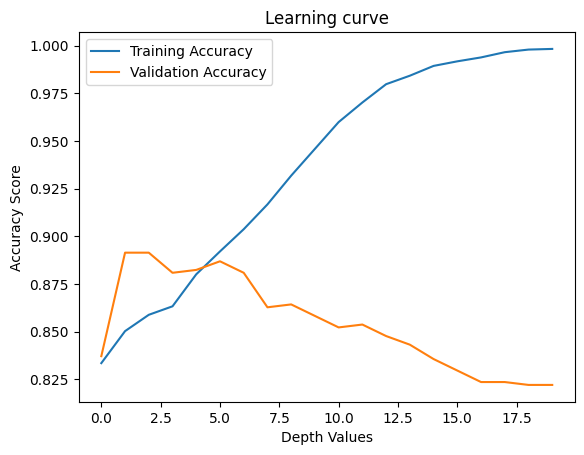

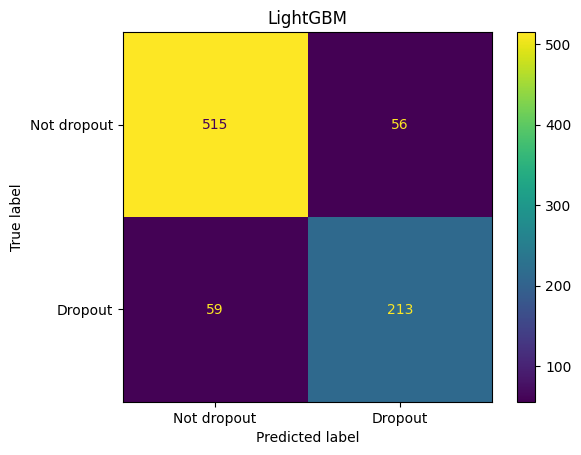

In [146]:
# Find the highest score
scores = [svm_acc, lr_acc, tree_acc, lgb_acc]
best_score = builtins.max(scores)
key_best_model = ''
best_model = ''

# Recreate dictionary_models from trained_models to ensure it's complete
list_of_models = ['Logistic Regression','Decision Tree', 'SVC', 'LightGBM']
dictionary_models = {list_of_models[i]: trained_models[i] for i in range(len(list_of_models))}

# Create a copy for modification
dict_models_copy = dictionary_models.copy()

# Generate a confusion matrix for the classifier that has the highest score
for key, value in accuracy_of_models.items():
    if best_score == value:
        key_best_model = key
        best_model = dict_models_copy[key_best_model]

        # Get predictions from the best model
        # Handle both PySpark models and sklearn-style models
        if hasattr(best_model, 'transform'):
            # PySpark model
            predictions = best_model.transform(test_data)
            predictions_pd = predictions.select("Target", "prediction").toPandas()
            y_pred = predictions_pd['prediction']
            y_true = predictions_pd['Target']
        else:
            # sklearn-style model (like LightGBM)
            y_pred = best_model.predict(X_test)
            y_true = y_test

        # Create confusion matrix using sklearn
        from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
        cm = confusion_matrix(y_true, y_pred)

        # Display confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=['Not dropout', 'Dropout'])
        disp.plot()
        plt.title(key_best_model)
        plt.show()

        # Remove the best performing model from the copy
        dict_models_copy.pop(key_best_model)
        break

Confusion matrix for other classifiers

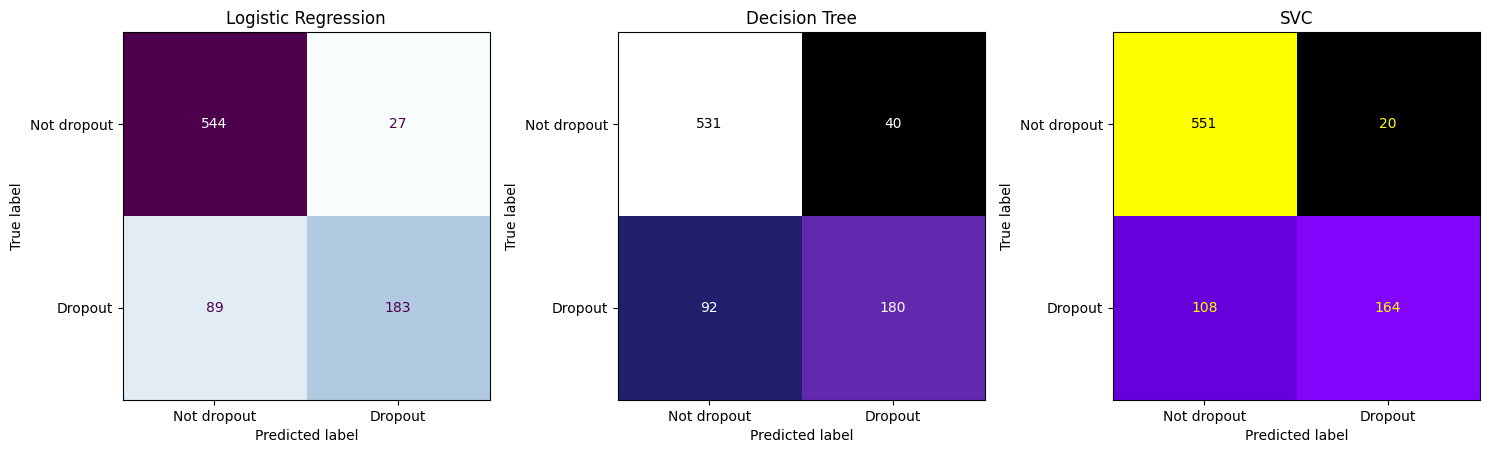

In [147]:
colors = ['BuPu', 'CMRmap', 'gnuplot', 'cividis', 'viridis']
position = 0

# Use dict_models_copy which has the best model removed
fig, ax = plt.subplots(1, len(dict_models_copy), figsize=(5*len(dict_models_copy), 5))

for key, value in dict_models_copy.items():
    # Get predictions from the model
    # Handle both PySpark models and sklearn-style models
    if hasattr(value, 'transform'):
        # PySpark model
        predictions = value.transform(test_data)
        predictions_pd = predictions.select("Target", "prediction").toPandas()
        y_pred = predictions_pd['prediction']
        y_true = predictions_pd['Target']
    else:
        # sklearn-style model (like LightGBM)
        y_pred = value.predict(X_test)
        y_true = y_test

    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Not dropout', 'Dropout'])
    disp.plot(cmap=colors[position], ax=ax[position], colorbar=False)
    ax[position].set_title(key)

    position += 1

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

In [148]:
Markdown(f"""
#### From the results above we can see that {best_model} perfoms best with the highest accuracy of {builtins.round(best_score * 100, 2)}%""")


#### From the results above we can see that LGBMClassifier(is_unbalance=True, learning_rate=0.05, max_depth=5,
               objective='binary', random_state=42, verbose=-1) perfoms best with the highest accuracy of 86.4%

Results

Feature Importances

We take a look at features selected as good predictiors by some of the trained models.

In [149]:
# Debug: Check what models are in trained_models
print(f"Number of models in trained_models: {len(trained_models)}")
for i, model in enumerate(trained_models):
    print(f"Model {i}: {type(model).__name__}")


Number of models in trained_models: 6
Model 0: LogisticRegressionModel
Model 1: DecisionTreeClassificationModel
Model 2: LinearSVCModel
Model 3: LGBMClassifier
Model 4: XGBClassifier
Model 5: CatBoostClassifier


In [150]:
# create list for features
feature = feature_columns

In [151]:
# Extract feature importance from EACH model
# (this is the step the supervisor asked for, to identify the causes of dropout)
models_dict = {name: trained_models[i] for i, name in enumerate(list_of_models)
               if i < len(trained_models)}

importances = {}

# PySpark models: coefficients (LogReg, LinearSVC) or featureImportances (Decision Tree)
if 'Logistic Regression' in models_dict:
    importances['Logistic Regression'] = pd.Series(
        np.abs(models_dict['Logistic Regression'].coefficients.toArray()), index=feature).sort_values()
if 'Decision Tree' in models_dict:
    importances['Decision Tree'] = pd.Series(
        models_dict['Decision Tree'].featureImportances.toArray(), index=feature).sort_values()
if 'SVC' in models_dict:
    importances['SVC'] = pd.Series(
        np.abs(models_dict['SVC'].coefficients.toArray()), index=feature).sort_values()

# The three ensemble models: scikit-learn's feature_importances_ attribute
for name in ['LightGBM', 'XGBoost', 'CatBoost']:
    if name in models_dict:
        importances[name] = pd.Series(
            models_dict[name].feature_importances_, index=feature).sort_values()

for name, s in importances.items():
    print(f"\n--- {name}: top 5 most important features ---")
    print(s.sort_values(ascending=False).head(5).to_string())


--- Logistic Regression: top 5 most important features ---
Curricular units 2nd sem (approved)    1.801868
Curricular units 2nd sem (enrolled)    0.888043
Curricular units 1st sem (approved)    0.849781
Tuition fees up to date                0.688361
Curricular units 2nd sem (credited)    0.505361

--- Decision Tree: top 5 most important features ---
Curricular units 2nd sem (approved)               0.819671
Tuition fees up to date                           0.128427
Course                                            0.051903
Curricular units 2nd sem (evaluations)            0.000000
Curricular units 2nd sem (without evaluations)    0.000000

--- SVC: top 5 most important features ---
Curricular units 2nd sem (approved)    0.691441
Tuition fees up to date                0.543409
Curricular units 2nd sem (enrolled)    0.493041
Curricular units 1st sem (approved)    0.421717
Curricular units 2nd sem (grade)       0.417193

--- LightGBM: top 5 most important features ---
Curricular units 2

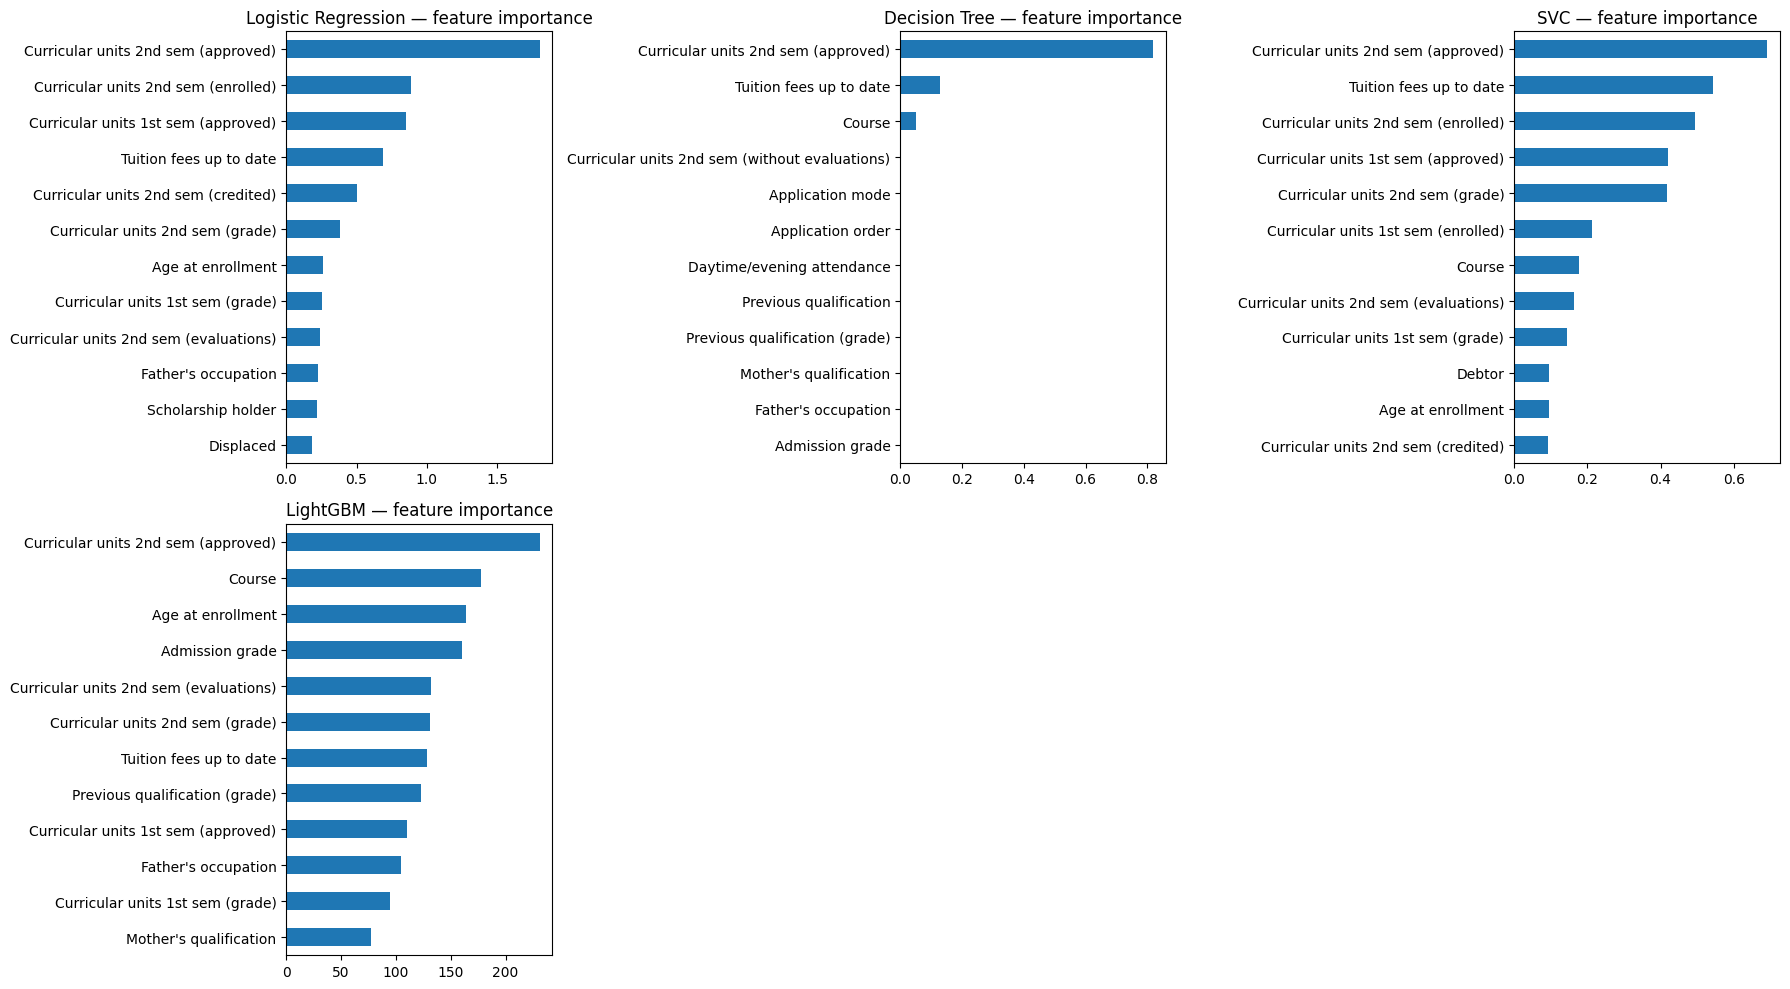

In [152]:
# Plot feature importance for every model
n = len(importances)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, ax = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(ax).reshape(-1)

for a, (name, s) in zip(axes, importances.items()):
    s.tail(12).plot(kind='barh', ax=a, title=f'{name} — feature importance')

for a in axes[n:]:
    a.axis('off')

plt.tight_layout()
plt.show()

### Observation

Across logistic regression, the decision tree, the linear SVM and the three ensemble models, the same block of features comes out on top: the **number of curricular units passed** (especially in semester 2) and the **tuition payment status**.

The agreement between very different model families is itself informative — it suggests the signal is in the data rather than an artefact of one particular algorithm.

/Users/macvn/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



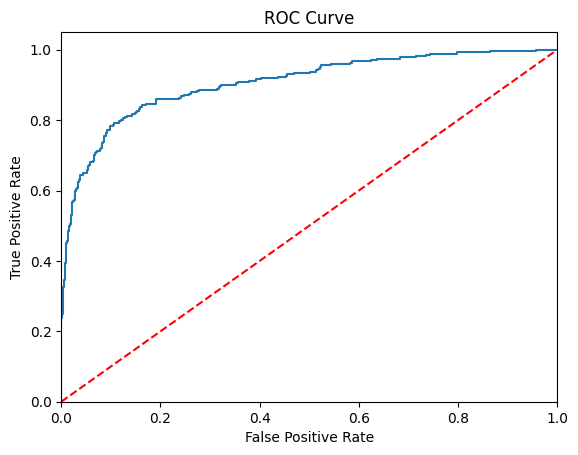



The AUC score is :0.91


In [153]:
# ROC curve for best model's predictions
# Handle both PySpark models and sklearn-style models
if hasattr(best_model, 'transform'):
    # PySpark model
    predictions = best_model.transform(test_data)
    predictions_pd = predictions.select("Target", "prediction", "probability").toPandas()

    # Extract probabilities for positive class
    if 'probability' in predictions_pd.columns:
        y_scores = predictions_pd['probability'].apply(lambda x: x[1] if len(x) > 1 else x[0])
    else:
        y_scores = predictions_pd['prediction']

    y_true = predictions_pd['Target']
else:
    # sklearn-style model (like LightGBM)
    y_scores = best_model.predict_proba(X_test)[:, 1]
    y_true = y_test

# Calculate ROC curve
fpr, tpr, threshold = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()
print('\n')
# Print the AUC score
print(f'The AUC score is :{builtins.round(roc_auc, 2)}')

### Reading the ROC curve

The AUC is computed from the **predicted probabilities** (`predict_proba`), not from the hard 0/1 labels. Using hard labels would collapse the curve to a single operating point and understate the AUC.

An AUC of around 0.90 means that, given one student who dropped out and one who did not, the model ranks the dropout as the riskier of the two about 90% of the time.

---

## Model explanation with SHAP — finding the causes of dropout

Feature importance shows *which* features matter, but not whether a feature pushes the risk **up or down**, and it cannot explain an **individual student**.

SHAP (SHapley Additive exPlanations) answers both. For tree models, `TreeExplainer` computes the values exactly and quickly.

Three levels of analysis follow:

| Level | Plot | Question answered |
|---|---|---|
| Global | `summary_plot(plot_type='bar')` | Which factors matter most across all students? |
| Global, with direction | `summary_plot` (beeswarm) | Does a high or low value of that factor **increase** the risk? |
| Individual | `waterfall` | Why is **this particular student** predicted to be at risk? |

> ⚠️ **How to phrase the findings.** SHAP describes the **behaviour of the model**, it does not prove causation. The results are therefore reported as **associated risk factors**, not as proven causes.

In [154]:
import shap

# X_test is a numpy array (converted from Spark), so the column names have to be
# re-attached, otherwise the SHAP plots show "Feature 0, Feature 1..." instead of names
X_test_df  = pd.DataFrame(X_test,  columns=feature_columns)
X_train_df = pd.DataFrame(X_train, columns=feature_columns)

ensemble_models = {'LightGBM': best_lgb_model,
                   'XGBoost':  best_xgb_model,
                   'CatBoost': best_cat_model}

shap_values_all, shap_tables = {}, {}

for name, model in ensemble_models.items():
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_test_df)
    if isinstance(sv, list):          # some versions return [class 0, class 1]
        sv = sv[1]
    sv = np.array(sv)
    shap_values_all[name] = (explainer, sv)

    shap_tables[name] = (pd.DataFrame({'feature': feature_columns,
                                       'mean_abs_shap': np.abs(sv).mean(axis=0)})
                         .sort_values('mean_abs_shap', ascending=False)
                         .reset_index(drop=True))

print('SHAP values computed for:', ', '.join(shap_values_all))
print(f'SHAP matrix shape: {sv.shape} (students × features)')

SHAP values computed for: LightGBM, XGBoost, CatBoost
SHAP matrix shape: (843, 30) (students × features)


/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



### Global level — which factors matter most

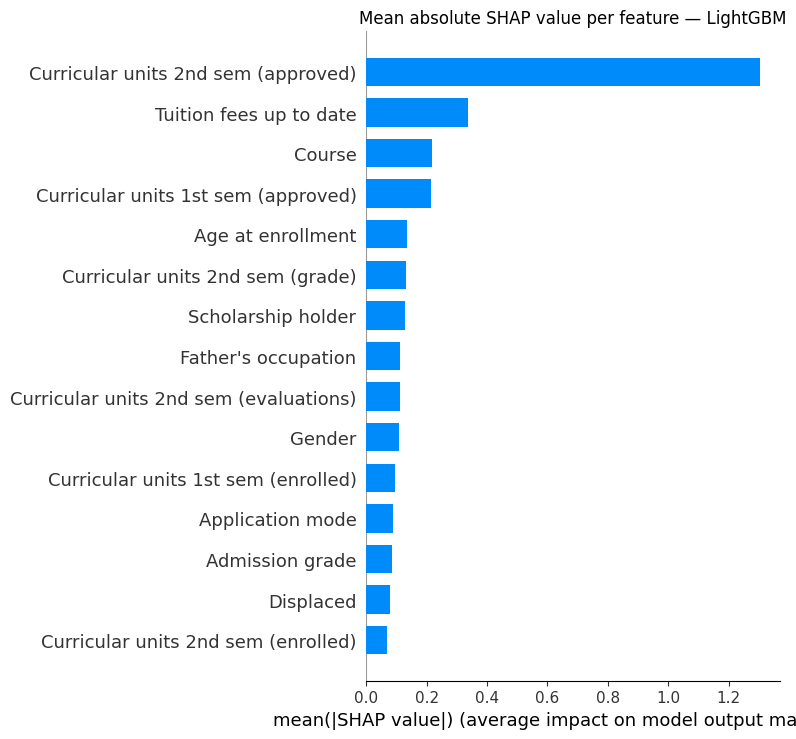

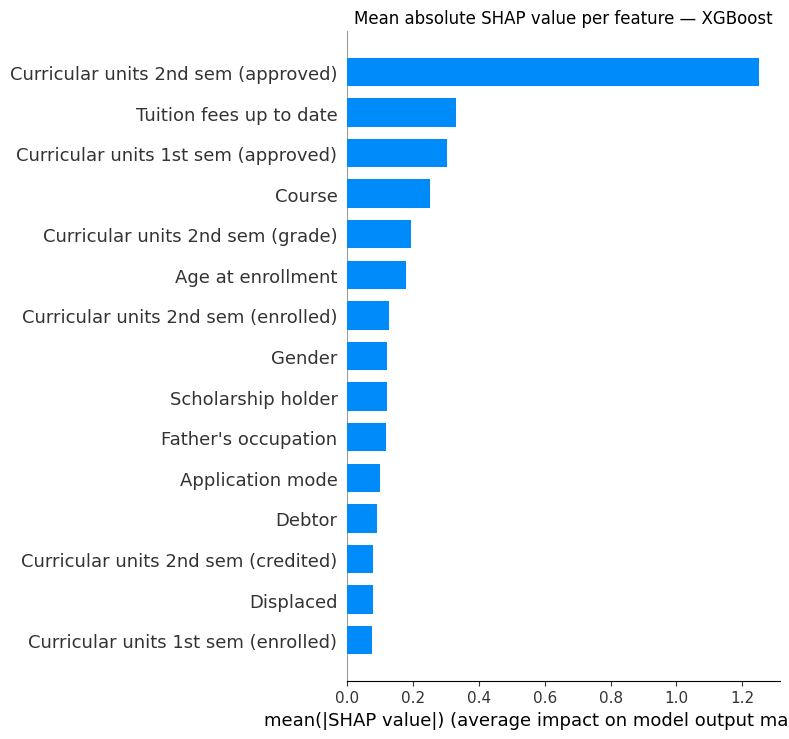

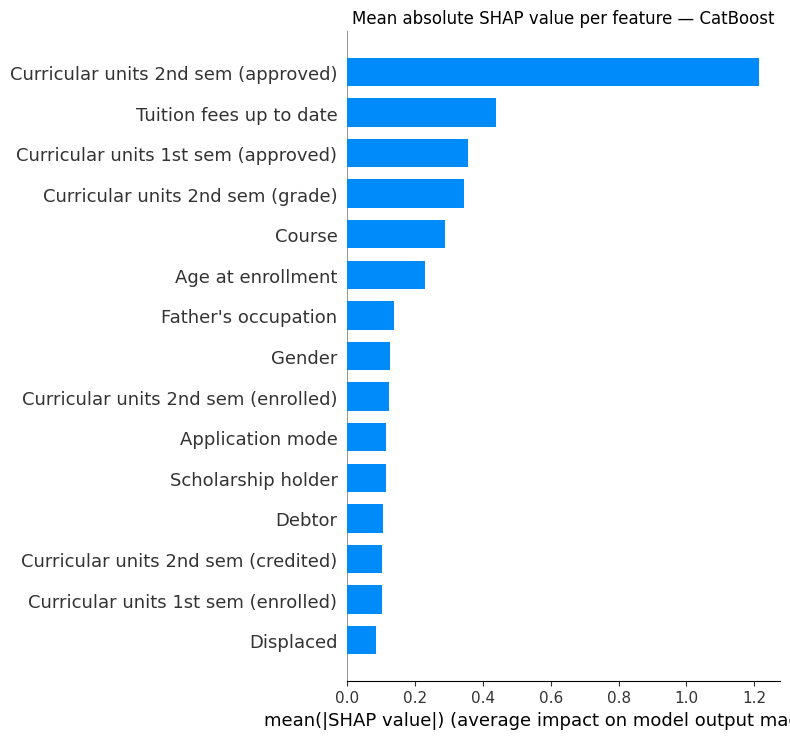

In [155]:
for name, (explainer, sv) in shap_values_all.items():
    shap.summary_plot(sv, X_test_df, plot_type='bar', max_display=15, show=False)
    plt.title(f'Mean absolute SHAP value per feature — {name}')
    plt.tight_layout()
    plt.show()

### Global level with direction — beeswarm plot

How to read it: each dot is one student. The horizontal axis is the contribution to the prediction — **further right means pushed towards "dropout"**. Colour is the value of the feature: **red = high, blue = low**.

For example, if `Tuition fees up to date` shows **blue dots on the right**, that means **unpaid tuition (a low value) increases the dropout risk**.

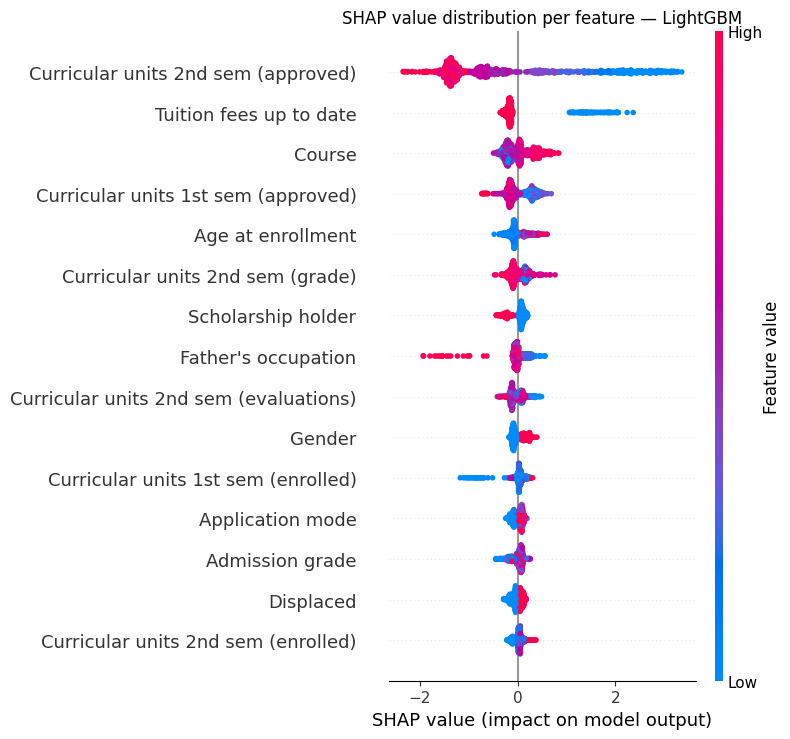

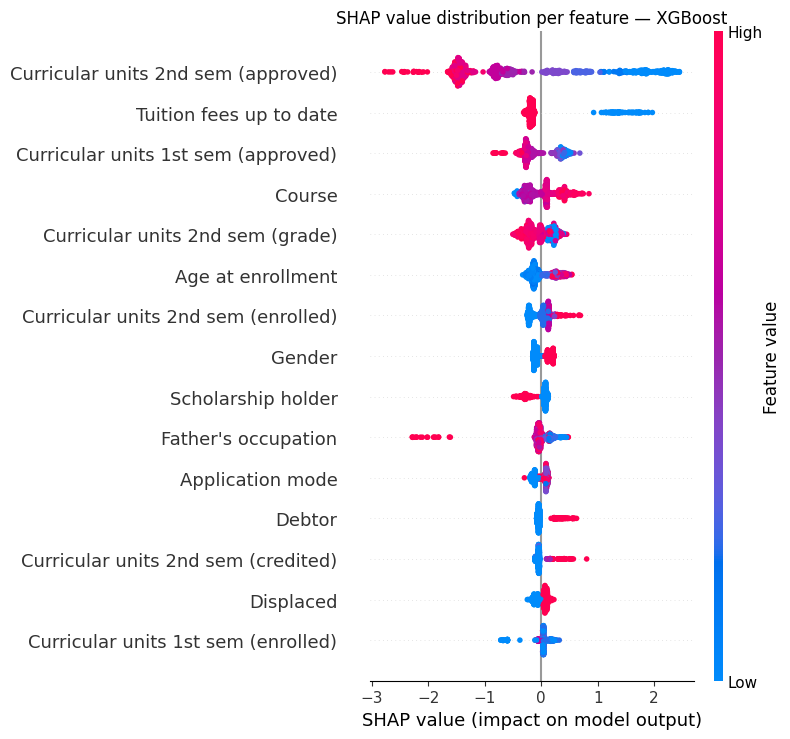

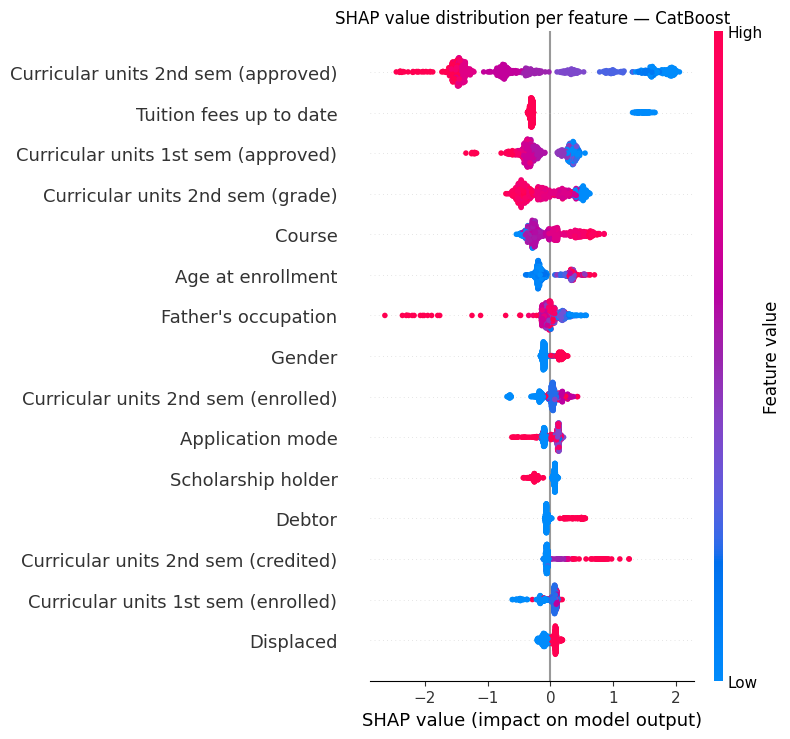

In [156]:
for name, (explainer, sv) in shap_values_all.items():
    shap.summary_plot(sv, X_test_df, max_display=15, show=False)
    plt.title(f'SHAP value distribution per feature — {name}')
    plt.tight_layout()
    plt.show()

### Individual level — why is this student at risk

The waterfall plot decomposes the prediction for **one student** into the contribution of each feature:

- **E[f(x)]** is the average risk across the dataset (the base value).
- **Red** bars are factors that **increase** that student's dropout risk.
- **Blue** bars are factors that **decrease** it (they keep the student enrolled).

This is exactly what an academic advisor needs: not just "this student is at risk", but **where the risk comes from**, so the right kind of support can be offered.

/Users/macvn/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



Illustrated student: index 590 · predicted dropout probability = 99.4% · actual label = Dropout


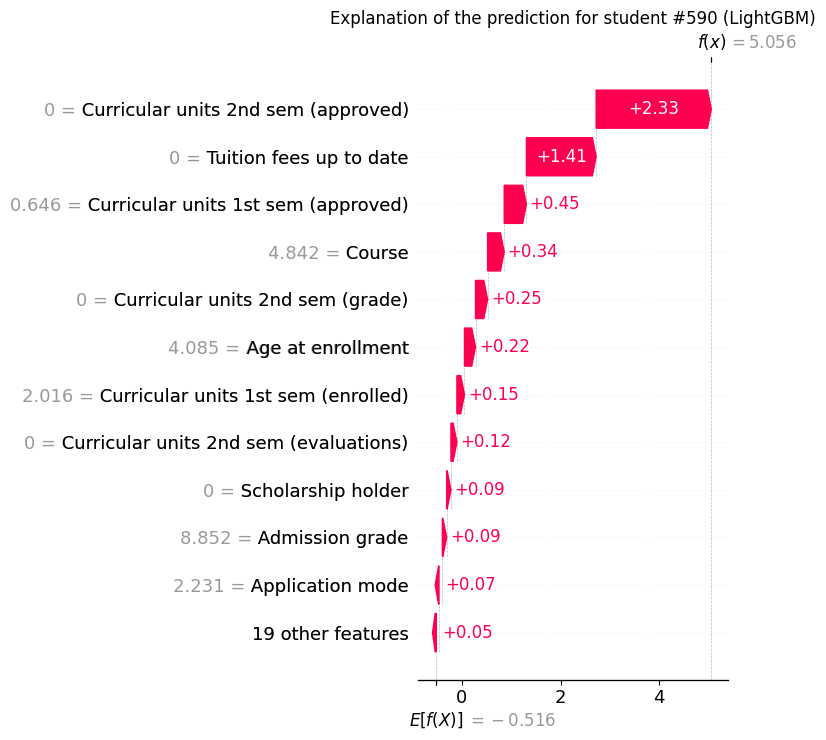

In [157]:
# Pick the highest-risk student in the test set as the illustration
risk = best_lgb_model.predict_proba(X_test)[:, 1]
student_index = int(np.argmax(risk))
print(f'Illustrated student: index {student_index} · '
      f'predicted dropout probability = {risk[student_index]:.1%} · '
      f'actual label = {"Dropout" if y_test[student_index] == 1 else "Not dropout"}')

explainer, sv = shap_values_all['LightGBM']
base = explainer.expected_value
if isinstance(base, (list, np.ndarray)) and np.ndim(base) > 0:
    base = base[-1]

shap.plots.waterfall(
    shap.Explanation(values=sv[student_index],
                     base_values=float(base),
                     data=X_test_df.iloc[student_index],
                     feature_names=feature_columns),
    max_display=12, show=False)
plt.title(f'Explanation of the prediction for student #{student_index} (LightGBM)')
plt.tight_layout()
plt.show()

### Summary of the risk factors

In [158]:
# Table of the top 10 risk factors according to each ensemble model
top = pd.DataFrame({name: t.head(10)['feature'].values
                    for name, t in shap_tables.items()},
                   index=[f'{i+1}' for i in range(10)])
print('Top 10 risk factors according to each model:')
display(top)

print('\nMean SHAP values (LightGBM):')
display(shap_tables['LightGBM'].head(10).round(4))

# Features in the top 10 of ALL THREE models — the stable set, safe to interpret
common = set(shap_tables['LightGBM'].head(10)['feature'])
for name in ['XGBoost', 'CatBoost']:
    common &= set(shap_tables[name].head(10)['feature'])
print(f'\nFactors in the top 10 of ALL THREE models ({len(common)}):')
for f in sorted(common):
    print(f'  - {f}')

Top 10 risk factors according to each model:


,LightGBM,XGBoost,CatBoost
1,Curricular units 2nd sem (approved),Curricular units 2nd sem (approved),Curricular units 2nd sem (approved)
2,Tuition fees up to date,Tuition fees up to date,Tuition fees up to date
3,Course,Curricular units 1st sem (approved),Curricular units 1st sem (approved)
4,Curricular units 1st sem (approved),Course,Curricular units 2nd sem (grade)
5,Age at enrollment,Curricular units 2nd sem (grade),Course
6,Curricular units 2nd sem (grade),Age at enrollment,Age at enrollment
7,Scholarship holder,Curricular units 2nd sem (enrolled),Father's occupation
8,Father's occupation,Gender,Gender
9,Curricular units 2nd sem (evaluations),Scholarship holder,Curricular units 2nd sem (enrolled)
10,Gender,Father's occupation,Application mode



Mean SHAP values (LightGBM):


,feature,mean_abs_shap
0,Curricular units 2nd sem (approved),1.3044
1,Tuition fees up to date,0.3361
2,Course,0.2180
3,Curricular units 1st sem (approved),0.2130
4,Age at enrollment,0.1359
5,Curricular units 2nd sem (grade),0.1324
6,Scholarship holder,0.1271
7,Father's occupation,0.1125
8,Curricular units 2nd sem (evaluations),0.1106
9,Gender,0.1097



Factors in the top 10 of ALL THREE models (8):
  - Age at enrollment
  - Course
  - Curricular units 1st sem (approved)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Father's occupation
  - Gender
  - Tuition fees up to date
